<br>
<a href="https://github.com/aperture-systems-lab">
    <img src="assets/banner_semillero.png" width="955" style="margin: 0px 0px 12px;"/>
</a>
<h1 style="line-height: 1.4;"><font color="#29c4d9"><b>Cómo funcionan las redes neuronales</b></font></h1>
<h2><b>Notebook 2: </b>Clasificación</h2>

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

import utils

torch.manual_seed(42)

----

<br>

## **Parte 0:** Nuestro objetivo

<div style="float: right; width: 36%; min-width: 170px; max-width: 300px; margin: 4px 0px 12px 30px;">
  <img src="assets/titanic.png" width="100%" alt="Hundimiento del Titanic"
       style="display: block; transform: rotate(-1.5deg);
              filter: drop-shadow(0px 12px 20px rgba(41, 196, 217, 0.35));"/>
</div>

Todos vimos *Titanic*, ¿sí o qué? Por si acaso, un recorderis pa los de peor memoria: 

La taquillera película de James Cameron (2.200 millones de dólares de recaudó) cuenta la historia de Jack Dawson (Leonardo Dicaprio), un joven pobre que viaja en tercera clase, y Rose DeWitt Bukater, una joven de primera clase comprometida con un millonario. Que terminan en una epopeya romantica en un viaje transatlantico.

Ambos el 15 de abril de 1912, durante su viaje inaugural, el RMS Titanic (considerado "insumergible") se hundió tras chocar con un iceberg. No había botes salvavidas para todos, y de las 2224 personas a bordo murieron 1502.

Al analizar los datos del evento vimos que el pobre muere más fácil que el rico y que se le daba prioridad a las mujeres y niños. Esto sugiere que dado un choque existen gente más probable en morir que otra, en el final casi estaba escrito: Rose era mujer y de primera clase mientras que Jack era hombre y de tercera clase.

El objetivo de este notebook es construir un modelo de **redes neuronales** que prediga **si un pasajero sobrevivió o no** a partir de sus datos.

<div style="clear: both;"></div>

----

<br>

## **Parte 1:** Los datos

Usaremos el registro de pasajeros del Titanic, el reto clásico de [Kaggle](https://www.kaggle.com/c/titanic), repartido en `train.csv` y `test.csv`.

De cada pasajero tenemos la siguiente información:

| Columna | Significado |
|---|---|
| `Pclass` | clase del tiquete (1ª, 2ª o 3ª) |
| `Sex` | sexo |
| `Age` | edad en años |
| `SibSp` | hermanos o pareja a bordo |
| `Parch` | padres o hijos a bordo |
| `Ticket`, `Fare`, `Cabin` | tiquete, tarifa pagada y camarote |
| `Embarked` | puerto de embarque (C, Q o S) |
| `Survived` | $1$ si sobrevivió, $0$ si no |

A diferencia del notebook anterior, acá la salida no es un número cualquiera sino una decisión entre dos opciones.

Por lo que queremos un modelo de la forma:

$$
F: x \rightarrow y \in \{0, 1\}
$$

que a partir de la información de un pasajero estime qué tan probable era que sobreviviera. 

A este tipo de problema se le llama **clasificación**. Mientras que el problema del notebook anterior se la llamaba **regresión**.

In [2]:
train_df = pd.read_csv("data/titanic/train.csv")
test_df = pd.read_csv("data/titanic/test.csv")

pasajeros_raw = pd.concat([train_df, test_df], ignore_index=True)

print("dimensiones:", pasajeros_raw.shape)
pasajeros_raw.head()

dimensiones: (1309, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


----

<br>

## **Parte 2:** Preparación de los datos

In [3]:
def preprocess(df):
    df = df.copy()

    # Quita signos de puntuación del inicio y final de cada palabra del nombre
    def normalize_name(x):
        return " ".join([v.strip(",()[].\"'") for v in x.split(" ")])

    # Devuelve la última parte del ticket (normalmente el número)
    def ticket_number(x):
        return x.split(" ")[-1]

    # Devuelve el prefijo del ticket unido con "_", o "NONE" si no tiene
    def ticket_item(x):
        items = x.split(" ")
        if len(items) == 1:
            return "NONE"
        return "_".join(items[0:-1])

    # Aplica la limpieza
    df["Name"] = df["Name"].apply(normalize_name)
    df["Ticket_number"] = df["Ticket"].apply(ticket_number)
    df["Ticket_item"] = df["Ticket"].apply(ticket_item)
    return df


preprocessed_df = preprocess(train_df)

# Selecionar las variables de entrada
input_features = list(preprocessed_df.columns)
input_features.remove("Ticket")
input_features.remove("PassengerId")
input_features.remove("Survived")
input_features.remove("Name")

print(f"Input features: {input_features}")
preprocessed_df.head(5)

Input features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked', 'Ticket_number', 'Ticket_item']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket_number,Ticket_item
0,1,0,3,Braund Mr Owen Harris,male,22.0,1,0,A/5 21171,7.2500,NaN,S,21171,A/5
1,2,1,1,Cumings Mrs John Bradley Florence Briggs Thayer,female,38.0,1,0,PC 17599,71.2833,C85,C,17599,PC
2,3,1,3,Heikkinen Miss Laina,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,3101282,STON/O2.
3,4,1,1,Futrelle Mrs Jacques Heath Lily May Peel,female,35.0,1,0,113803,53.1000,C123,S,113803,NONE
4,5,0,3,Allen Mr William Henry,male,35.0,0,0,373450,8.0500,NaN,S,373450,NONE


In [4]:
preprocessed_train_df, preprocessed_serving_df = train_test_split(
    preprocessed_df,
    test_size=0.2,
    random_state=42
)

print(f"{len(preprocessed_train_df)} ejemplos de entrenamiento, {len(preprocessed_serving_df)} ejemplos de prueba.")

712 ejemplos de entrenamiento, 179 ejemplos de prueba.


In [5]:
def to_tensors(df, input_features):
    df = df[input_features + ["Survived"]].copy()

    # Rellena valores faltantes
    df = df.fillna({
        "Age": df["Age"].median(), 
        "Fare": df["Fare"].median(),
        "Embarked": "S", 
        "Cabin": "NONE"})

    # Convierte cada columna de texto en números enteros
    for col in df.select_dtypes(include=["object", "string"]).columns:
        df[col] = pd.factorize(df[col])[0]

    X = torch.tensor(df[input_features].values, dtype=torch.float32)
    y = torch.tensor(df["Survived"].values, dtype=torch.float32).unsqueeze(1)

    return X, y


X_train, y_train = to_tensors(preprocessed_train_df, input_features)
X_val, y_val = to_tensors(preprocessed_serving_df, input_features)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: torch.Size([712, 10])
y_train shape: torch.Size([712, 1])


----

<br>

## **Parte 3:** ¿Qué queremos maximizar?

### Accuracy

Porcentaje de predicciones correctas hechas por el modelo

$$
Accuracy = \frac{Predicciones\ correctas}{Todas\ las\ predicciones}
$$

- **Maximizar**
- Puede ser poco confiable con datos desbalanceados

De todos los pasajeros, ¿en cuántos acertó el modelo, ya sea que sobrevivieron o no?

In [ ]:
def accuracy(y_real, y_pred):
    ### Inicio del código
    correctas = torch.sum(y_pred == y_real)
    total = y_real.shape[0]

    output = correctas / total

    ### fin del código
    return output

### Confusion Matriz
![https://cdn-images-1.medium.com/max/679/1*YXQWFPQP7lzLBgv9K0hCPg.png](assets/embarazo.png)

In [9]:
def matriz_confusion(y_real, y_pred):
    ### Inicio del código
    vp = torch.sum((y_pred == 1) & (y_real == 1))   
    fp = torch.sum((y_pred == 1) & (y_real == 0))   
    fn = torch.sum((y_pred == 0) & (y_real == 1))
    vn = torch.sum((y_pred == 0) & (y_real == 0))   

    output = torch.tensor([[vn, fp],
                           [fn, vp]])

    ### fin del código
    return output
# 

### Precision 

Mide qué tan seguido son correctas las predicciones positivas del modelo

$$
Precision = \frac{Verdaderos\ positivos}{Verdaderos\ positivos + Falsos\ positivos}
$$

- **Maximizar**
- Usar cuando los falsos positivos son costosos

De los pasajeros que el modelo dijo que sobrevivieron, ¿cuántos sobrevivieron realmente?

In [ ]:
def precision(y_real, y_pred):
    ### Inicio del código
    vp = torch.sum((y_pred == 1) & (y_real == 1))
    fp = torch.sum((y_pred == 1) & (y_real == 0))

    output = vp / (vp + fp)

    ### fin del código
    return output

### Recall

Mide qué tanto identifica el modelo los verdaderos positivos entre todos los positivos reales

$$
Recall = \frac{Verdaderos\ positivos}{Verdaderos\ positivos + Falsos\ negativos}
$$

- **Maximizar**
- Usar cuando los falsos negativos son costosos

De todos los pasajeros que realmente sobrevivieron, ¿a cuántos logró detectar el modelo?


In [ ]:
def recall(y_real, y_pred):
    ### Inicio del código
    vp = torch.sum((y_pred == 1) & (y_real == 1))
    fn = torch.sum((y_pred == 0) & (y_real == 1))

    output = vp / (vp + fn)

    ### fin del código
    return output

### F1 Score

Equilibra los falsos positivos y los falsos negativos

$$
F1\ Score = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

- **Maximizar**
- Preferible a la accuracy con datos desbalanceados

¿Qué tan bien identifica el modelo a los sobrevivientes, sin equivocarse demasiado al decir que alguien sobrevivió ni dejando escapar a demasiados que sí lo hicieron?

In [ ]:
def f1_score(y_real, y_pred):
    ### Inicio del código
    p = precision(y_real, y_pred)
    r = recall(y_real, y_pred)

    output = 2 * (p * r) / (p + r)

    ### fin del código
    return output

----

<br>

## **Parte 4:** ¿Con quién vamos a comparar?

Época 200 — pérdida: 0.48743703961372375
Época 400 — pérdida: 0.4552854895591736
Época 600 — pérdida: 0.44975340366363525
Época 800 — pérdida: 0.4484497606754303
Época 1000 — pérdida: 0.44768789410591125
Época 1200 — pérdida: 0.44709324836730957
Época 1400 — pérdida: 0.4466480016708374
Época 1600 — pérdida: 0.4463386535644531
Época 1800 — pérdida: 0.4461398720741272
Época 2000 — pérdida: 0.4460221230983734


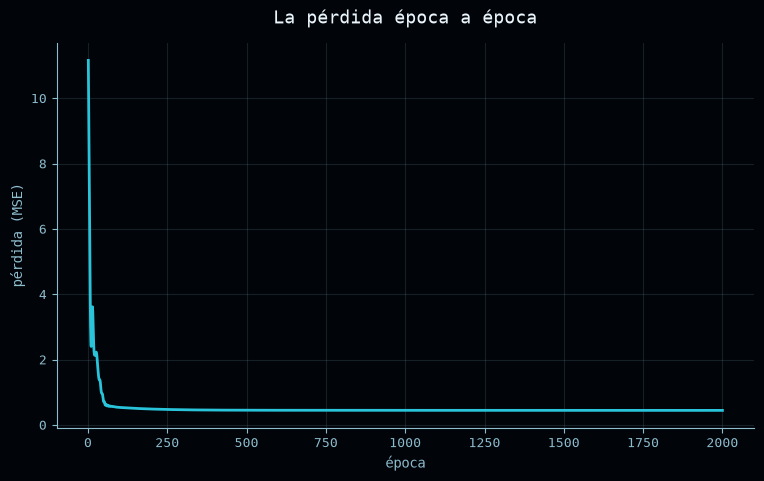

Precisión en prueba: 0.788


In [8]:
class RegresionLogistica(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return self.linear(x)


modelo = RegresionLogistica(X_train.shape[1])
funcion_perdida = nn.BCEWithLogitsLoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.01)

historial_log = []

for epoca in range(2000):
    optimizador.zero_grad()                            # 1. borrar los gradientes viejos
    predicciones = modelo(X_train)                     # 2. predecir
    perdida = funcion_perdida(predicciones, y_train)   # 3. medir el error
    perdida.backward()                                 # 4. calcular gradientes
    optimizador.step()                                 # 5. actualizar parametros

    historial_log.append(perdida.item())

    if (epoca + 1) % 200 == 0:
        print(f"Época {epoca + 1} — pérdida: {perdida}")

# Graficando la perdida
utils.dibujar_perdida(historial_log)

# Evaluando en el conjunto de prueba
with torch.no_grad():
    probabilidades = torch.sigmoid(modelo(X_val))      # convertir a probabilidad (0 a 1)
    predicciones = (probabilidades >= 0.5).float()     # sobrevive si es 0.5 o más
    precision = (predicciones == y_val).float().mean()

print(f"Precisión en prueba: {precision:.3f}")

----

<br>

## **Parte 4:** La red

In [7]:
utils.dibujar_metricas(perdidas, titulo="La pérdida época a época", y_etiqueta="entropía cruzada")
utils.dibujar_metricas(exactitudes, titulo="La exactitud época a época", y_etiqueta="exactitud")

NameError: name 'perdidas' is not defined

In [ ]:
print(f"exactitud en entrenamiento: {exactitud(modelo, x_entrenar_n, y_entrenar):.3f}")
print(f"exactitud en prueba      : {exactitud(modelo, x_prueba_n, y_prueba):.3f}")
print(f"decir que todos mueren    : {1 - y_prueba.float().mean().item():.3f}  <- el mínimo a superar")

exactitud en entrenamiento: 0.853
exactitud en prueba      : 0.832
decir que todos mueren    : 0.704  <- el mínimo a superar


In [ ]:
with torch.no_grad():
    elegida = modelo(x_prueba_n).argmax(dim=1)

matriz = torch.zeros(2, 2, dtype=torch.long)
for real, predicha in zip(y_prueba, elegida):
    matriz[real, predicha] += 1

print("filas: lo que pasó | columnas: lo que dijo la red\n")
print(pd.DataFrame(matriz.numpy(),
                   index=["murió", "sobrevivió"],
                   columns=["dijo murió", "dijo sobrevivió"]))

filas: lo que pasó | columnas: lo que dijo la red

            dijo murió  dijo sobrevivió
murió              118                8
sobrevivió          22               31


-----

<br>

### **Siguiente notebook:**

[`03_tictactoe.ipynb`](03_tictactoe.ipynb)

### <font color="#29c4d9">**Notebook 2 listo.**</font>

<br>

---

<div style="margin-top: 50px;"><center><a href="https://github.com/aperture-systems-lab"><img src="assets/banner_logo.png" width="955"/></a></center></div>